# Tutorial 1: VrsDataProvider Basics

## Introduction

[Aria Gen2](https://www.projectaria.com/) glasses are Meta’s dedicated research tool in an always-on glasses form factor. The data recorded by Aria Gen2 glasses are stored in VRS files, where each VRS file captures time-synchronized data streams from various sensors, such cameras, IMUs, audio, and more.
The **VrsDataProvider** interface provides a unified way to access multimodal sensor data from these VRS files.

**What you'll learn:**

- How to create a `VrsDataProvider` from a VRS file.  
- Discover available sensor data streams, and check their configurations  
- Retrieve data using either sequential (index-based) or temporal (timestamp-based) access APIs.   
- Learn about timing domains and time query options

**Prerequisites:**
- Basic Python knowledge and a general understanding of multimodal sensor data.
- Download Aria Gen2 sample data from [link](https://www.projectaria.com/async/sample/download/?bucket=core&filename=aria_gen2_sample_data_1.vrs)

### ⚠️ Important Notes
- **Google Colab Users:**  
  If you encounter a `ModuleNotFoundError: No module named 'rerun'` error after installing `rerun-sdk`, Colab may not recognize the new package until the runtime is restarted.  
  **Fix:** Go to **Runtime → Restart session and run all**.

- **Visualization Issue :**  
  If a Rerun visualization window does not appear, this may be due to a known caching issue. Simply re-run the visualization cell to resolve it.

## Setup Environment (Google Colab)

If running on Google Colab, install `projectaria-tools` and set up the environment, and also download sample Aria Gen2 data.

In [1]:
from pathlib import Path

# Where does everything live ? Everything sits inside the repository now, so the
# notebooks are in <repo>/notebooks and every data folder is a sibling of that one. We
# work the repository out from the notebook's own location, which means you can rename
# the repository or move it somewhere else entirely and not a single path below breaks.
NOTEBOOKS = Path.cwd()
REPO      = NOTEBOOKS.parent

# Running this from somewhere other than the notebooks folder ? Then uncomment the line
# below, point it at the repository and everything underneath it keeps working.
# REPO = Path("/Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics")

# The heavy folders live inside the repository, which means git would cheerfully try to
# take all 2.8 GB of them if we let it. Every one of them is named in .gitignore
# instead, so they sit right here beside the code while never reaching GitHub. One
# warning follows from that. Never run git clean -x in here, because that is the command
# which deletes ignored files and the recordings cannot be made a second time.
RECORDINGS = REPO / "recordings"   # the vrs files, far too big for git
MODELS     = REPO / "models"       # yolo and sam weights, downloadable again
CACHE      = REPO / "cache"        # exported frames, the mp4, cached centroids
OUTPUTS    = REPO / "outputs"      # the deliverables, and these do go in git

# Anything we write into should exist before we try to write into it.
OUTPUTS.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

print("repo:      ", REPO)
print("recordings:", RECORDINGS)
print("models:    ", MODELS)
print("cache:     ", CACHE)
print("outputs:   ", OUTPUTS)

# A wrong working directory would quietly send every write below into some other folder,
# and we would only find out much later when a file turns up missing. So we stop here
# instead of guessing.
assert RECORDINGS.is_dir(), f"no recordings folder at {RECORDINGS}, set REPO by hand above"
assert MODELS.is_dir(),     f"no models folder at {MODELS}, set REPO by hand above"

repo:       /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics
recordings: /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings
models:     /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/models
cache:      /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/cache
outputs:    /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/outputs


In [2]:
import sys
import os
import subprocess

google_colab_env = 'google.colab' in str(get_ipython())

if google_colab_env:
    if sys.version_info >= (3, 13):
        raise RuntimeError(
            f"❌ project-aria-tools requires Python 3.10–3.12, but this session is running Python {sys.version.split()[0]}.\n\n"
            "To fix this:\n"
            "1. Go to top menu: Runtime -> Change runtime type\n"
            "2. Set 'Runtime Version' dropdown to '2026.07' (Python 3.12)\n"
            "3. Click Save and re-run."
        )

    print(f"✅ Python {sys.version.split()[0]} detected. Environment is compatible with project-aria-tools!")
    print("Running from Google Colab, installing projectaria_tools and downloading sample data")

    # Install projectaria-tools
    !pip install projectaria-tools==2.3.0

    # Set up data path
    vrs_sample_path = "./vrs_sample_data"

    # Sample VRS file URL
    vrs_url = "https://www.projectaria.com/async/sample/download/?bucket=core&filename=aria_gen2_sample_data_1.vrs"
    vrs_filename = "aria_gen2_sample_data_1.vrs"
    vrs_file_path = os.path.join(vrs_sample_path, vrs_filename)

    # Download commands
    command_list = [
        f"mkdir -p {vrs_sample_path}",
        f'curl -o {vrs_file_path} -C - -O -L "{vrs_url}"'
    ]

    # Execute the commands for downloading dataset
    print(f"Downloading VRS sample data to {vrs_file_path}...")
    for command in command_list:
        !$command

    print(f"Download complete! VRS file saved to: {vrs_file_path}")

    # Running this command to trigger early failure of importing ReRun.
    # Should be resolved by restarting the Colab session.
    import rerun as rr
else:
    # For local environment, user needs to specify their own VRS file path
    vrs_file_path = str(RECORDINGS / "pouring_scooping_1_20260918_160639.vrs")
    print(f"Using local recording: {vrs_file_path}")


Using local recording: /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings/pouring_scooping_1_20260918_160639.vrs


## Basic File Loading

The `create_vrs_data_provider($FILE_PATH)` factory function will create **a \`vrs\_data\_provider\` object**. This object is **your entry point** for accessing VRS data.

In [3]:
from projectaria_tools.core import data_provider

# Load local VRS file
vrs_data_provider = data_provider.create_vrs_data_provider(vrs_file_path)

[ProgressLogger][INFO]: 2026-09-25 01:53:18: Opening /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings/pouring_scooping_1_20260918_160639.vrs...
[TelemetryLogger][INFO]: RecordFileReader::doOpenFile, diskfile: success, 969970952
[VRSIndexRecord][WARNING]: 12 record(s) not sorted properly. Sorting index.
[MultiRecordFileReader][DEBUG]: Opened file '/Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings/pouring_scooping_1_20260918_160639.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 211-1/camera-et-left activated
[VrsDataProvider][INFO]: streamId 211-2/camera-et-right activated
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 231-1/mic activated
[VrsDataProvider][INFO]: streamId 246-1/temperature activated
[VrsDataProvider][INFO]: streamId 247-1/baro0 activated
[VrsDataProvider][INFO]: streamId 248-1/ppg activated


## Stream Discovery and Navigation

### Understanding Stream IDs

A VRS file contains multiple **streams**, each storing data from a specific sensor or on-device algorithm result.

Each VRS stream is identified by a unique **`StreamId`** (e.g. `1201-1`), consisting `RecordableTypeId` (sensor type, e.g. `1201`, standing for “SLAM camera”), and an `instance_id` (for multiple sensors of the same type, e.g. `-1`, standing for “instance \#1 of this sensor type”). Below are some common `RecordableTypeId` in Aria recordings. Full definitions of all Recordable Types are given in this wiki page (TODO: Add website page), or refer to [the \`StreamId.h\` file in the VRS repo](https://github.com/facebookresearch/vrs/blob/main/vrs/StreamId.h#L49).

| RecordableTypeId | Description |
| :---- | :---- |
| 214 | RGB camera stream |
| 1201 | SLAM camera stream |
| 211 | EyeTracking camera stream |
| 1202 | IMU sensor stream |
| 231 | Audio sensor stream |
| 373 | EyeGaze data stream from on-device EyeTracking algorithm. |

### Query StreamId By Label

In [4]:
# Get all available streams
all_streams = vrs_data_provider.get_all_streams()
print(f"Found {len(all_streams)} streams in the VRS file:")

# Print out each stream id, and their corresponding sensor label
for stream_id in all_streams:
    label = vrs_data_provider.get_label_from_stream_id(stream_id)
    print(f" --- Data stream {stream_id}'s label is: {label}")

Found 23 streams in the VRS file:
 --- Data stream 211-1's label is: camera-et-left
 --- Data stream 211-2's label is: camera-et-right
 --- Data stream 214-1's label is: camera-rgb
 --- Data stream 231-1's label is: mic
 --- Data stream 246-1's label is: temperature
 --- Data stream 247-1's label is: baro0
 --- Data stream 248-1's label is: ppg
 --- Data stream 281-1's label is: gps-app
 --- Data stream 282-1's label is: wps
 --- Data stream 283-1's label is: bluetooth
 --- Data stream 371-1's label is: handtracking
 --- Data stream 371-2's label is: vio
 --- Data stream 371-3's label is: vio_high_frequency
 --- Data stream 373-1's label is: eyegaze
 --- Data stream 500-1's label is: als
 --- Data stream 502-1's label is: battery-status
 --- Data stream 1201-1's label is: slam-front-left
 --- Data stream 1201-2's label is: slam-front-right
 --- Data stream 1201-3's label is: slam-side-left
 --- Data stream 1201-4's label is: slam-side-right
 --- Data stream 1202-1's label is: imu-left


In [5]:
# Find a specific stream's StreamId by sensor label
print("Seeking RGB data stream...")
rgb_stream_id = vrs_data_provider.get_stream_id_from_label("camera-rgb")
if rgb_stream_id is not None:
    print(f"Found camera-rgb stream in VRS file: {rgb_stream_id}")
else:
    print("Cannot find camera-rgb stream in VRS file.")

Seeking RGB data stream...
Found camera-rgb stream in VRS file: 214-1


## Sensor Data Query APIs

1. ### Query by index
The query-by-index API allows you to retrieve the k-th data sample from a specific stream using the following syntax:
```python
get_${SENSOR}_data_by_index(stream_id, index)
```
where `${SENSOR}` can be replaced by any sensor data type available in Aria VRS. See here for [a full list of supported ${SENSOR}](https://github.com/facebookresearch/projectaria_tools/blob/main/core/data_provider/VrsDataProvider.h#L377)

This API is commonly used for sequential processing—such as iterating through all frames of a single stream—or when you know the exact frame number you want to query within a specific stream.

**Important Note**:
The indices in each stream are independent and not correlated across different sensor streams. For example, the i-th RGB image does not necessarily correspond to the i-th SLAM image. This is because different sensors may operate at different frequencies or have missing frames, so their data streams are not synchronized by index.




In [6]:
# Visualize with Rerun
import rerun as rr
import numpy as np
rr.init("rerun_viz_query_by_index")

# Get number of samples in stream
num_samples = vrs_data_provider.get_num_data(rgb_stream_id)
print(f"RGB stream has a total of {num_samples} frames\n")

# The tutorial version logged only the first ten frames, which at thirty frames
# a second is a third of a second of footage. We want the whole recording, so we
# step across every frame index instead of stopping at ten.
# Do we log every single one ? No. Two thousand full resolution frames would make
# the viewer sluggish, so we take every fifth, which still gives us about six
# frames a second of playback across the full duration.
step = 5

for i in range(0, num_samples, step):
    image_data, image_record = vrs_data_provider.get_image_data_by_index(
        rgb_stream_id, i
    )

    # Access image properties
    timestamp_ns = image_record.capture_timestamp_ns

    # Process image data
    if image_data.is_valid():
        rr.set_time("device_time", duration=np.timedelta64(timestamp_ns, "ns"))
        rr.log("camera_rgb", rr.Image(image_data.to_numpy_array()).compress(jpeg_quality=90))

# A short summary instead of a timestamp per frame, since printing four hundred
# lines would bury everything else in the notebook.
print(f"Logged {len(range(0, num_samples, step))} frames, every {step}th across the recording")

rr.notebook_show()

RGB stream has a total of 2012 frames

Logged 403 frames, every 5th across the recording


HTML(value='<div id="5ce663f9-759e-4569-a05b-23a7d4df3a6e"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

2. ### Query by Timestamp: TimeDomain and TimeQueryOptions
A key feature of Aria devices is the ability to capture time-synchronized, multi-modal sensor data. To help you access this data with precise temporal control, `projectaria_tools` provides a comprehensive suite of time-based APIs.

The most commonly used is the **timestamp-based query**:

```python
get_${SENSOR}_by_time_ns(stream_id, time_ns, time_domain=None, time_query_options=None)
```
where `${SENSOR}` can be replaced by any sensor data type available in Aria VRS. See here for [a full list of supported ${SENSOR}](https://github.com/facebookresearch/projectaria_tools/blob/main/core/data_provider/VrsDataProvider.h#L377)

This API is often used to synchronize data across multiple sensor streams, fetch sensor data at specific timestamps, or perform temporal analysis.

#### TimeDomain and TimeQueryOptions

When querying sensor data by timestamp, two important concepts are:

- **TimeDomain**: Specifies the time reference for your query.
- **TimeQueryOptions**: Controls how the API selects data relative to your requested timestamp.

Below are all available options for each:

#### TimeDomain Options

| Name        | Description                                                                                      | Typical Use Case                        |
|-------------|--------------------------------------------------------------------------------------------------|-----------------------------------------|
| RECORD_TIME  | Timestamp stored directly in the VRS index. Fast access, but time domain may vary.               | Quick access, not recommended for sync. |
| DEVICE_TIME  | Accurate device capture time. All sensors on the same Aria device share this domain.             | **Recommended for single-device data.** |
| HOST_TIME    | Arrival time in the host computer’s domain. May not be accurate.                                 | Debugging, host-side analysis.          |
| TIME_CODE    | [Aria-Gen1 only] TimeSync server’s domain using external time-code devices, accurate across devices in multi-device capture.                       | Multi-device synchronization.           |
| TIC_SYNC     | [Aria-Gen1 only] TimeSync server’s domain using tic-sync, accurate for multi-device capture.      | Multi-device synchronization.           |
| SubGhz      | [Aria-Gen2 only] TimeSync server’s domain using SubGhz signals, accurate for multi-device capture.           | Multi-device synchronization.           |
| Utc         | UTC time domain, only seconds-level accuracy.                                                    | Coarse, global time reference.          |

#### TimeQueryOptions

| Name    | Description                                                                                                 |
|---------|-------------------------------------------------------------------------------------------------------------|
| Before  | Returns the last valid data with `timestamp <= t_query`.                                                    |
| After   | Returns the first valid data with `timestamp >= t_query`.                                                   |
| Closest | Returns the data sample closest to `t_query`. If two are equally close, returns the one **before** the query.   |

> For detailed usage and best practices—especially for time-sync across multiple devices—see **Tutorial_4**.

In [7]:
from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions

rr.init("rerun_viz_query_by_timestamp")

# Get time bounds for RGB images
first_timestamp_ns = vrs_data_provider.get_first_time_ns(rgb_stream_id, TimeDomain.DEVICE_TIME)
last_timestamp_ns = vrs_data_provider.get_last_time_ns(rgb_stream_id, TimeDomain.DEVICE_TIME)

# Query specific timestamp
target_time_ns = first_timestamp_ns + int(1e9)  # 1 second later
image_data, image_record = vrs_data_provider.get_image_data_by_time_ns(
    rgb_stream_id,
    target_time_ns,
    TimeDomain.DEVICE_TIME,
    TimeQueryOptions.CLOSEST
)

actual_time_ns = image_record.capture_timestamp_ns
print(f"Requested RGB data that is closest to: {target_time_ns} ns, Got closest sample at: {actual_time_ns} ns")

# Plot RGB and SLAM images across the whole recording
camera_label_list = ["camera-rgb", "slam-front-left", "slam-front-right", "slam-side-left", "slam-side-right"]
camera_stream_ids = [vrs_data_provider.get_stream_id_from_label(camera_label) for camera_label in camera_label_list]

# The tutorial version looped a fixed ten times, which covered only the first ten
# seconds. We work out the real length instead, so the loop follows the recording
# rather than a hardcoded number.
duration_ns = last_timestamp_ns - first_timestamp_ns
duration_s = duration_ns / 1e9

# How often do we sample ? One snapshot a second keeps this manageable, because
# every pass pulls five cameras rather than one.
step_ns = int(1e9)
num_steps = int(duration_s)

print(f"Recording is {duration_s:.1f} seconds long, taking {num_steps} snapshots from {len(camera_label_list)} cameras")

query_timestamp_ns = first_timestamp_ns
for _ in range(num_steps):
    for label, stream_id in zip(camera_label_list, camera_stream_ids):
        # Query each camera's data according to query timestamp
        image_data, image_record = vrs_data_provider.get_image_data_by_time_ns(
            stream_id,
            query_timestamp_ns,
            TimeDomain.DEVICE_TIME,
            TimeQueryOptions.CLOSEST)
        # note that the actual timestamp of the image data is stored within image_record. It can be different from query_time.
        capture_time_ns = image_record.capture_timestamp_ns

        # Plot to Rerun
        if image_data.is_valid():
            rr.set_time("device_time", duration=np.timedelta64(capture_time_ns, "ns"))
            rr.log(label, rr.Image(image_data.to_numpy_array()).compress(jpeg_quality=90))

    query_timestamp_ns = query_timestamp_ns + step_ns

rr.notebook_show()

Requested RGB data that is closest to: 659134566084 ns, Got closest sample at: 659134293116 ns
Recording is 67.0 seconds long, taking 67 snapshots from 5 cameras


HTML(value='<div id="46170369-1908-4609-9424-49916c278147"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

In [8]:
# Same two calls you already used, aimed at the on-device perception streams.
for label in ["handtracking", "eyegaze", "vio"]:
    sid = vrs_data_provider.get_stream_id_from_label(label)
    n = vrs_data_provider.get_num_data(sid)
    print(f"{label}: stream {sid}, {n} samples")

handtracking: stream 371-1, 2011 samples
eyegaze: stream 373-1, 2012 samples
vio: stream 371-2, 670 samples


In [9]:
# Ask the provider what it can do, rather than guessing method names.
print([m for m in dir(vrs_data_provider) if "hand" in m.lower()])
print([m for m in dir(vrs_data_provider) if "eye" in m.lower() or "gaze" in m.lower()])

['get_hand_pose_configuration', 'get_hand_pose_data_by_index', 'get_hand_pose_data_by_time_ns', 'get_interpolated_hand_pose_data']
['get_eye_gaze_configuration', 'get_eye_gaze_data_by_index', 'get_eye_gaze_data_by_time_ns']


In [10]:
# Pull the very first hand pose sample and see what's inside it.
hand_sid = vrs_data_provider.get_stream_id_from_label("handtracking")
sample = vrs_data_provider.get_hand_pose_data_by_index(hand_sid, 0)

# The image getter returned a pair, so check the shape of this one before assuming.
print("type:", type(sample))
print()

# List the public attributes, which is where the wrist and landmark data will be.
print([a for a in dir(sample) if not a.startswith("_")])

type: <class '_core_pybinds.mps.hand_tracking.HandTrackingResult'>

['left_hand', 'right_hand', 'tracking_timestamp']


In [11]:
# Count how often each hand is actually present, since a hand out of view produces nothing.
n = vrs_data_provider.get_num_data(hand_sid)
left_count = 0
right_count = 0
first_left_index = None

for i in range(n):
    s = vrs_data_provider.get_hand_pose_data_by_index(hand_sid, i)
    if s.left_hand is not None:
        left_count += 1
        # Remember the first one we see, so we can inspect a real hand rather than an empty slot.
        if first_left_index is None:
            first_left_index = i
    if s.right_hand is not None:
        right_count += 1

print(f"total samples: {n}")
print(f"left hand present in:  {left_count}")
print(f"right hand present in: {right_count}")
print(f"first sample containing a left hand: {first_left_index}")
print()

# Now open up one real hand and see what a single hand actually carries.
sample = vrs_data_provider.get_hand_pose_data_by_index(hand_sid, first_left_index)
print("type:", type(sample.left_hand))
print([a for a in dir(sample.left_hand) if not a.startswith("_")])

total samples: 2011
left hand present in:  1658
right hand present in: 1664
first sample containing a left hand: 74

type: <class '_core_pybinds.mps.hand_tracking.HandTrackingResult.OneSide'>
['confidence', 'get_palm_position_device', 'get_wrist_position_device', 'landmark_positions_device', 'transform_device_wrist', 'wrist_and_palm_normal_device']


points collected: (1658, 3)
first point: [-0.09629273  0.14274645  0.25633436]
x range: -0.3590008318424225 to 0.18145355582237244
y range: -0.11216491460800171 to 0.6326742768287659
z range: -0.03816656768321991 to 0.5459139943122864
confidence range: 0.6878836154937744 to 0.999901294708252


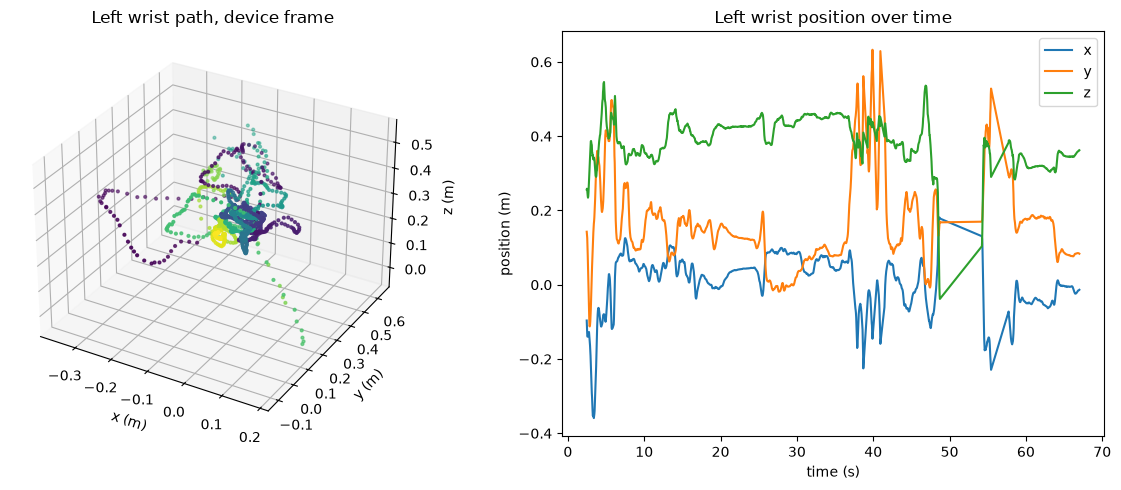

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# We walk every sample in the stream and keep only the ones where a left hand was actually seen.
# Remember that roughly one sample in twenty five has no left hand at all, so we cannot assume
# every index gives us a position.
positions = []
confidences = []
indices = []

for i in range(vrs_data_provider.get_num_data(hand_sid)):
    s = vrs_data_provider.get_hand_pose_data_by_index(hand_sid, i)
    # Is there a left hand in this sample ? If not, we skip it rather than inserting a fake value.
    if s.left_hand is None:
        continue
    # This is a method rather than a plain attribute, so we call it to get the three numbers back.
    positions.append(s.left_hand.get_wrist_position_device())
    # We keep the confidence alongside, because a low confidence point may be worth filtering later.
    confidences.append(s.left_hand.confidence)
    # We keep the original index too, so we can map any point back to its moment in the recording.
    indices.append(i)

# Turning the list into an array gives us column slicing, which makes the plotting far easier.
positions = np.array(positions)
confidences = np.array(confidences)

# A quick sanity check before we draw anything. Do the numbers look like metres ?
print("points collected:", positions.shape)
print("first point:", positions[0])
print("x range:", positions[:, 0].min(), "to", positions[:, 0].max())
print("y range:", positions[:, 1].min(), "to", positions[:, 1].max())
print("z range:", positions[:, 2].min(), "to", positions[:, 2].max())
print("confidence range:", confidences.min(), "to", confidences.max())

# Now the trajectory itself, drawn in three dimensions.
fig = plt.figure(figsize=(12, 5))

# On the left we draw the path through space, which is the demonstration we eventually hand to a robot.
ax = fig.add_subplot(1, 2, 1, projection="3d")
# We colour the line by sample index so that we can see which end is the beginning.
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2],
           c=indices, cmap="viridis", s=4)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Left wrist path, device frame")

# On the right we plot each axis against time, because a flat curve here means the hand was resting.
ax2 = fig.add_subplot(1, 2, 2)
# Our samples arrive at thirty per second, so dividing the index by thirty gives us seconds.
seconds = np.array(indices) / 30.0
ax2.plot(seconds, positions[:, 0], label="x")
ax2.plot(seconds, positions[:, 1], label="y")
ax2.plot(seconds, positions[:, 2], label="z")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("position (m)")
ax2.set_title("Left wrist position over time")
ax2.legend()

plt.tight_layout()
plt.show()

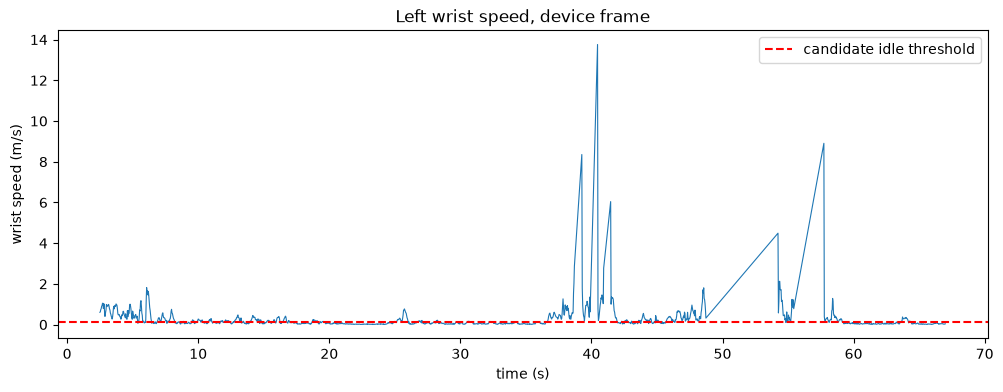

median speed: 0.10076401091041505
95th percentile speed: 0.9281128370200848
fraction of time below 0.15 m/s: 0.6125528062764032


In [13]:
# Position tells us where the hand is. Speed tells us whether it is doing anything,
# and that is what actually separates a demonstration from a pause.
# We take the difference between consecutive positions and divide by the time between them.
deltas = np.diff(positions, axis=0)

# Each row of deltas is a small step in x, y and z. The length of that step is the distance moved.
step_distances = np.linalg.norm(deltas, axis=1)

# Our samples are about one thirtieth of a second apart, so distance over that gives metres per second.
speeds = step_distances * 30.0

# The speed array is one shorter than the position array, so we drop the first timestamp to match.
speed_seconds = seconds[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(speed_seconds, speeds, linewidth=0.8)

# A horizontal line gives us something to judge against. Anything below it is arguably a pause.
ax.axhline(0.15, color="red", linestyle="--", label="candidate idle threshold")
ax.set_xlabel("time (s)")
ax.set_ylabel("wrist speed (m/s)")
ax.set_title("Left wrist speed, device frame")
ax.legend()
plt.show()

# A few summary numbers to quote rather than eyeball.
print("median speed:", np.median(speeds))
print("95th percentile speed:", np.percentile(speeds, 95))
print("fraction of time below 0.15 m/s:", (speeds < 0.15).mean())

steps total: 1657
steps spanning a dropout: 5
largest gap, in frames: 165


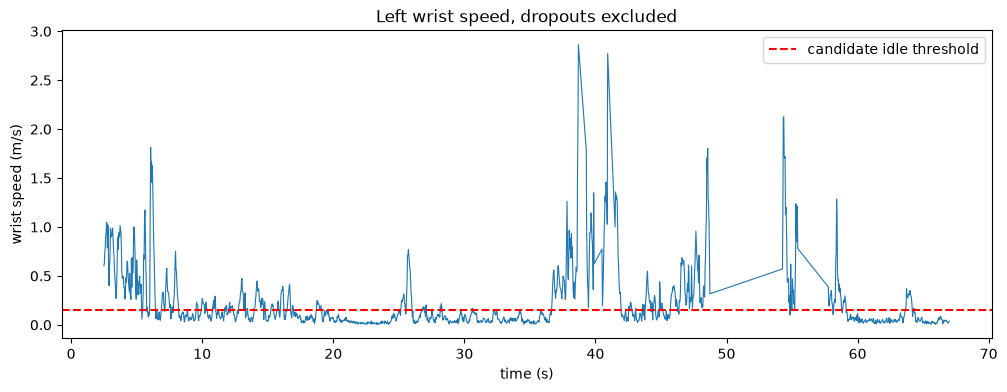

median speed: 0.10006229413487958
95th percentile: 0.901636592161566
max speed: 2.8648797183368004
fraction below 0.15 m/s: 0.614406779661017


In [14]:
# The kept samples are not evenly spaced, because we dropped every frame with no left hand.
# So we must use the real time gap for each step instead of assuming a fixed one.
index_array = np.array(indices)

# The number of frames between one kept sample and the next, converted to seconds.
step_frames = np.diff(index_array)
dt = step_frames / 30.0

deltas = np.diff(positions, axis=0)
step_distances = np.linalg.norm(deltas, axis=1)

# Dividing by the real gap gives an honest speed even where frames were missing.
speeds = step_distances / dt

# A step that spans a dropout is not an observation of motion, it is two observations
# with an unknown amount of movement in between. Are we entitled to plot it ? No.
# So we keep only the steps where the two samples were genuinely adjacent.
is_contiguous = step_frames == 1

print("steps total:", len(speeds))
print("steps spanning a dropout:", (~is_contiguous).sum())
print("largest gap, in frames:", step_frames.max())

clean_speeds = speeds[is_contiguous]
clean_seconds = seconds[1:][is_contiguous]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clean_seconds, clean_speeds, linewidth=0.8)
ax.axhline(0.15, color="red", linestyle="--", label="candidate idle threshold")
ax.set_xlabel("time (s)")
ax.set_ylabel("wrist speed (m/s)")
ax.set_title("Left wrist speed, dropouts excluded")
ax.legend()
plt.show()

print("median speed:", np.median(clean_speeds))
print("95th percentile:", np.percentile(clean_speeds, 95))
print("max speed:", clean_speeds.max())
print("fraction below 0.15 m/s:", (clean_speeds < 0.15).mean())

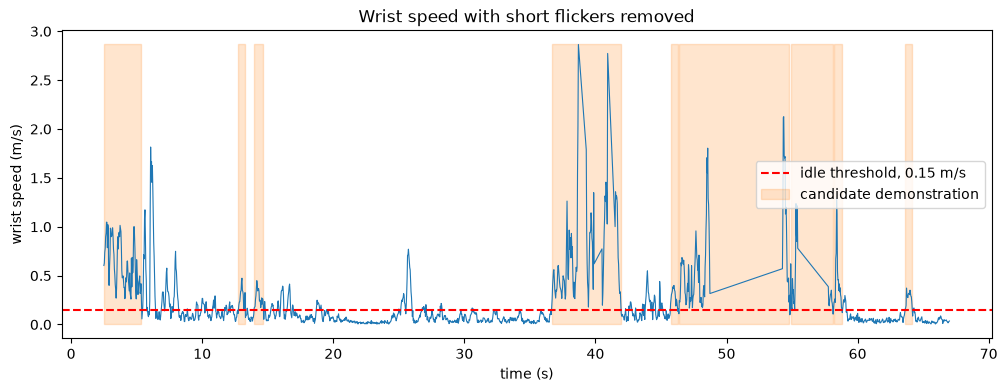

active fraction before smoothing: 0.39
active fraction after smoothing:  0.24


In [15]:
# A raw threshold flickers whenever the speed crosses it, which produces stripes
# rather than segments. Are those stripes demonstrations ? No. So we keep only
# runs that last at least half a second and treat shorter ones as noise.
import numpy as np

min_frames = 15  # about half a second at thirty samples per second

active = clean_speeds >= 0.15
smoothed = active.copy()

# We walk the array finding each unbroken run of the same value, then flip any
# active run that is too short to be a real action.
start = 0
for i in range(1, len(active) + 1):
    if i == len(active) or active[i] != active[start]:
        if active[start] and (i - start) < min_frames:
            smoothed[start:i] = False
        start = i

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clean_seconds, clean_speeds, linewidth=0.8, color="tab:blue")
ax.axhline(0.15, color="red", linestyle="--", label="idle threshold, 0.15 m/s")
ax.fill_between(clean_seconds, 0, clean_speeds.max(), where=smoothed,
                color="tab:orange", alpha=0.2, label="candidate demonstration")
ax.set_xlabel("time (s)")
ax.set_ylabel("wrist speed (m/s)")
ax.set_title("Wrist speed with short flickers removed")
ax.legend()

plt.savefig(OUTPUTS / "wrist_speed_segmented_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"active fraction before smoothing: {active.mean():.2f}")
print(f"active fraction after smoothing:  {smoothed.mean():.2f}")